In [3]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

dataset = load_dataset("dair-ai/emotion")

train_df = dataset["train"].to_pandas()

label_names = dataset["train"].features["label"].names

train_df["emotion"] = train_df["label"].map(
    dict(enumerate(label_names))
)

In [4]:
print("Training dataset shape:", train_df.shape)

Training dataset shape: (16000, 3)


In [5]:
emotion_counts = train_df["emotion"].value_counts()

print(emotion_counts)

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


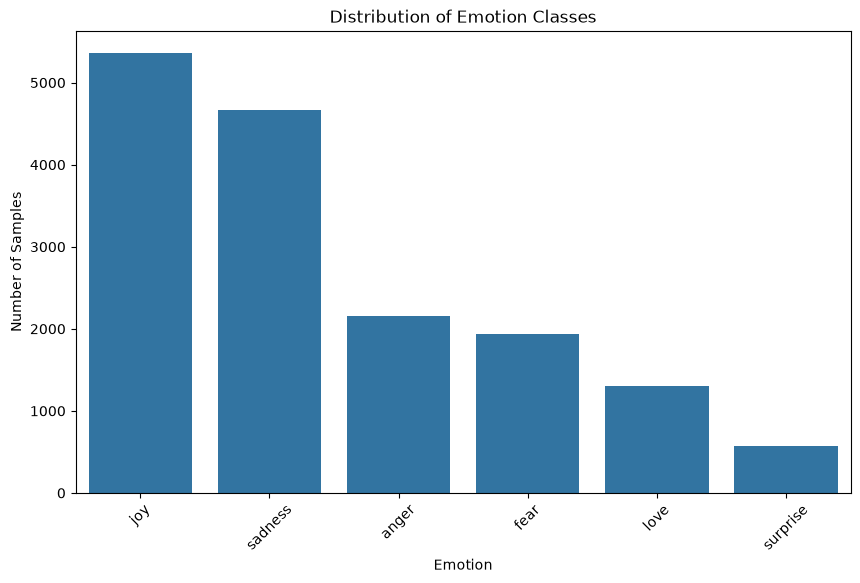

In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=train_df,
    x="emotion",
    order=emotion_counts.index
)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [7]:
#  Text Length Analysis

train_df["char_count"] = train_df["text"].str.len()

train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text", "char_count", "word_count"]].head()

,text,char_count,word_count
0,i didnt feel humiliated,23,4
1,i can go from feeling so hopeless to so damned...,108,21
2,im grabbing a minute to post i feel greedy wrong,48,10
3,i am ever feeling nostalgic about the fireplac...,92,18
4,i am feeling grouchy,20,4


In [8]:
train_df[["char_count", "word_count"]].describe()

,char_count,word_count
count,16000.000000,16000.000000
mean,96.845812,19.166313
std,55.904953,10.986905
min,7.000000,2.000000
25%,53.000000,11.000000
50%,86.000000,17.000000
75%,129.000000,25.000000
max,300.000000,66.000000


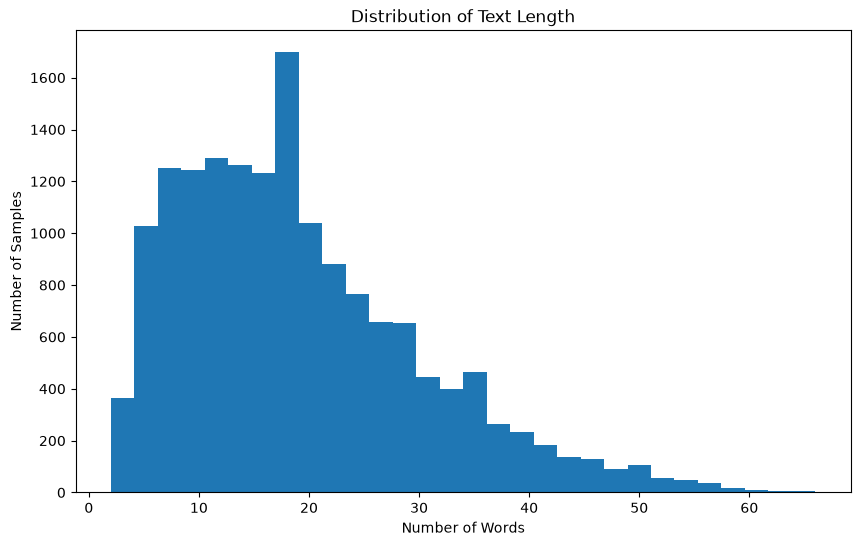

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["word_count"],
    bins=30
)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")

plt.show()

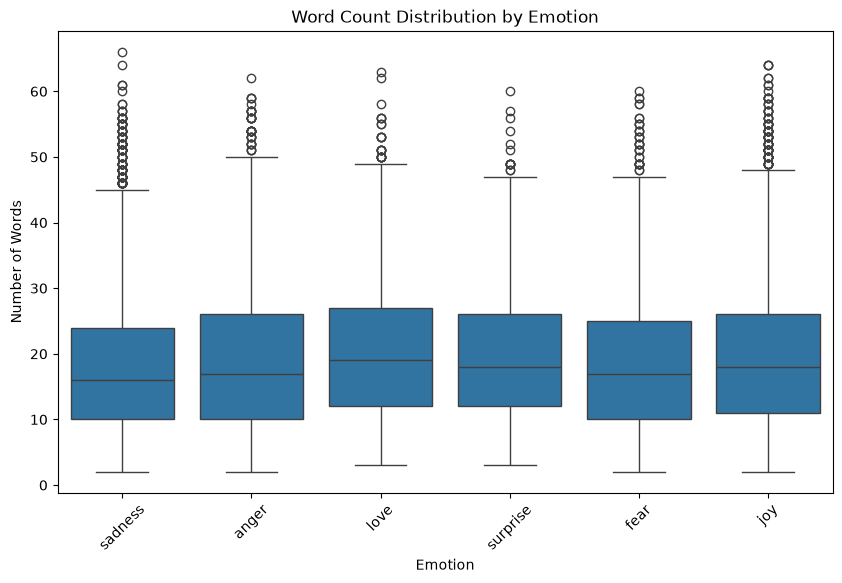

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="emotion",
    y="word_count"
)

plt.title("Word Count Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Number of Words")
plt.xticks(rotation=45)

plt.show()

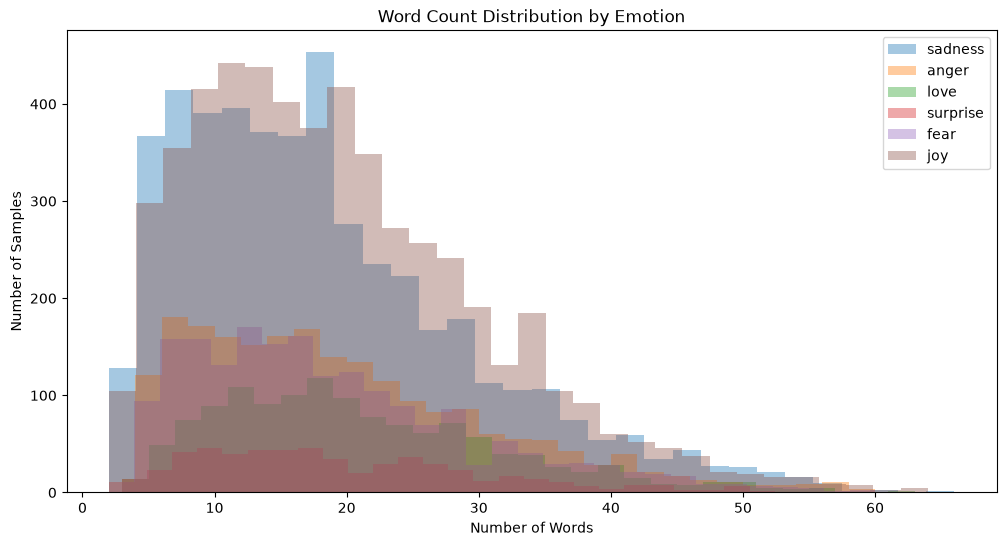

In [11]:
plt.figure(figsize=(12, 6))

for emotion in train_df["emotion"].unique():
    subset = train_df[train_df["emotion"] == emotion]

    plt.hist(
        subset["word_count"],
        bins=30,
        alpha=0.4,
        label=emotion
    )

plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")
plt.title("Word Count Distribution by Emotion")
plt.legend()

plt.show()

In [12]:
correlation_matrix = train_df[
    ["label", "char_count", "word_count"]
].corr()

correlation_matrix

,label,char_count,word_count
label,1.000000,0.027222,0.022723
char_count,0.027222,1.000000,0.983854
word_count,0.022723,0.983854,1.000000


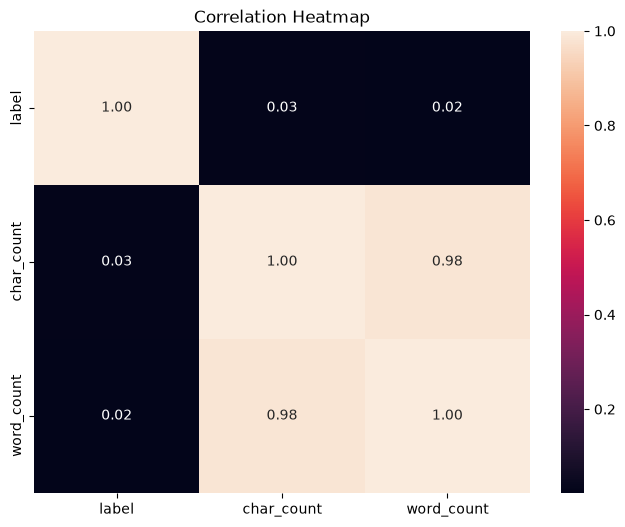

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
all_words = " ".join(train_df["text"]).split()

word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('i', 25859),
 ('feel', 11183),
 ('and', 9589),
 ('to', 8972),
 ('the', 8370),
 ('a', 6200),
 ('feeling', 5112),
 ('that', 5112),
 ('of', 4990),
 ('my', 4283),
 ('in', 3433),
 ('it', 3127),
 ('like', 2908),
 ('so', 2527),
 ('for', 2431),
 ('im', 2430),
 ('me', 2309),
 ('but', 2255),
 ('was', 2227),
 ('have', 2224)]

In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [19]:
filtered_words = [
    word
    for word in all_words
    if word.lower() not in ENGLISH_STOP_WORDS
]

filtered_word_frequency = Counter(filtered_words)

filtered_word_frequency.most_common(20)

[('feel', 11183),
 ('feeling', 5112),
 ('like', 2908),
 ('im', 2430),
 ('just', 1391),
 ('really', 942),
 ('t', 897),
 ('know', 853),
 ('time', 794),
 ('little', 736),
 ('people', 654),
 ('want', 644),
 ('think', 596),
 ('ive', 587),
 ('life', 551),
 ('make', 523),
 ('bit', 516),
 ('love', 500),
 ('going', 487),
 ('dont', 482)]

In [20]:
joy_text = train_df[
    train_df["emotion"] == "joy"
]["text"]

joy_words = " ".join(joy_text).split()

joy_word_frequency = Counter(joy_words)

joy_word_frequency.most_common(20)

[('i', 8518),
 ('feel', 3928),
 ('and', 3273),
 ('to', 3232),
 ('the', 2991),
 ('a', 2120),
 ('that', 1905),
 ('of', 1651),
 ('feeling', 1539),
 ('my', 1378),
 ('in', 1267),
 ('it', 1028),
 ('like', 1006),
 ('is', 858),
 ('have', 850),
 ('for', 807),
 ('im', 799),
 ('so', 797),
 ('this', 739),
 ('me', 737)]

In [21]:
joy_filtered_words = [
    word
    for word in joy_words
    if word.lower() not in ENGLISH_STOP_WORDS
]

joy_filtered_frequency = Counter(joy_filtered_words)

joy_filtered_frequency.most_common(20)

[('feel', 3928),
 ('feeling', 1539),
 ('like', 1006),
 ('im', 799),
 ('just', 423),
 ('really', 309),
 ('time', 290),
 ('t', 259),
 ('know', 240),
 ('make', 225),
 ('want', 203),
 ('people', 203),
 ('think', 198),
 ('good', 196),
 ('love', 191),
 ('little', 189),
 ('pretty', 184),
 ('life', 181),
 ('going', 179),
 ('ive', 176)]

In [22]:
sadness_text = train_df[
    train_df["emotion"] == "sadness"
]["text"]

sadness_words = " ".join(sadness_text).split()

sadness_filtered_words = [
    word
    for word in sadness_words
    if word.lower() not in ENGLISH_STOP_WORDS
]

sadness_filtered_frequency = Counter(sadness_filtered_words)

sadness_filtered_frequency.most_common(20)

[('feel', 3299),
 ('feeling', 1523),
 ('like', 864),
 ('im', 683),
 ('just', 422),
 ('really', 276),
 ('know', 275),
 ('t', 272),
 ('ive', 217),
 ('time', 199),
 ('little', 194),
 ('want', 179),
 ('people', 176),
 ('life', 176),
 ('think', 175),
 ('bit', 169),
 ('dont', 158),
 ('things', 155),
 ('make', 139),
 ('day', 137)]

In [23]:
joy_total = sum(joy_filtered_frequency.values())
sadness_total = sum(sadness_filtered_frequency.values())

vocabulary = (
    set(joy_filtered_frequency)
    | set(sadness_filtered_frequency)
)

word_comparison = []

for word in vocabulary:
    joy_rate = (
        joy_filtered_frequency[word] + 1
    ) / (
        joy_total + len(vocabulary)
    )

    sadness_rate = (
        sadness_filtered_frequency[word] + 1
    ) / (
        sadness_total + len(vocabulary)
    )

    ratio = joy_rate / sadness_rate

    word_comparison.append((word, ratio))

joy_distinctive_words = sorted(
    word_comparison,
    key=lambda x: x[1],
    reverse=True
)

joy_distinctive_words[:20]

[('successful', 60.14862142008369),
 ('cute', 53.274493257788414),
 ('honored', 48.978163156353865),
 ('respected', 48.118897136066956),
 ('superior', 47.259631115780046),
 ('festive', 46.400365095493136),
 ('clever', 45.54109907520623),
 ('friendly', 45.54109907520623),
 ('resolved', 43.82256703463241),
 ('productive', 43.82256703463241),
 ('mellow', 43.82256703463241),
 ('energetic', 42.9633010143455),
 ('intelligent', 42.9633010143455),
 ('supporting', 42.10403499405859),
 ('welcomed', 40.38550295348477),
 ('carefree', 40.38550295348477),
 ('virtuous', 39.52623693319786),
 ('fabulous', 39.52623693319786),
 ('artistic', 38.66697091291095),
 ('invigorated', 37.80770489262404)]

# 2.13 EDA Summary

The exploratory analysis produced several important findings:

1. The dataset contains six emotion categories with an imbalanced class distribution. Joy and sadness are the largest classes, while surprise is the smallest.

2. Most text samples are relatively short, with an average length of approximately 19 words.

3. Text-length distributions overlap considerably across emotion categories, suggesting that word count alone is not a strong predictor of emotion.

4. Character count and word count have a very strong positive correlation, indicating that they capture similar information.

5. The dataset contains many common conversational words, while terms such as "feel" and "feeling" occur frequently.

6. After removing common stop words, more meaningful vocabulary becomes visible. However, contraction and negation-related forms such as "dont" are present, suggesting that aggressive text cleaning should be avoided.

7. Joy and Sadness share substantial vocabulary, demonstrating that simple word-frequency rules are insufficient for reliable emotion classification.

8. The EDA findings support the use of text-based feature extraction techniques such as TF-IDF, followed by supervised machine learning algorithms.

These findings will guide the text preprocessing and feature engineering stages of the project.